### Import libraries

In [25]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
from tsl.data import SpatioTemporalDataset

DATA_FOLDER = '../data/'

### Load data

In [26]:

df = pd.read_csv(os.path.join(DATA_FOLDER, 'EWZ.csv'), sep=";")


# First row: AKS, I don't know what it is
AKS = df.iloc[0]
# Second row: Unit: MWh, constant value
df.drop(index=[0, 1], inplace=True)

# delta time: 15 minutes

print(df.shape)
df.head()

C:\Users\matya\AppData\Local\Temp\ipykernel_13620\1295655669.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(DATA_FOLDER, 'EWZ.csv'), sep=";")


(340462, 102)


,Name,Wärmezähler UST 10 Spitalstrasse 6 Regionalspital Surselva WZ11,Wärmezähler Ölkessel Spital WZ10,Wärmezähler UST 62 Via Fontanivas Schwimmbad,Wärmezähler Holzkessel WT01 Direkt WZ1,Wärmezähler Holzkessel WT02 ORC WZ2,Wärmezähler Holzkessel WT03 AbWärmezähler WZ3,Wärmezähler Ölkessel Zentrale WZ5,Wärmezähler Ölkessel Zentrale REKU WZ8,Wärmezähler Fernleitung WZ6,...,Wärmezähler Spitalstrasse 7 UST 84,Wärmezähler Spitalstrasse 8 UST 85,Wärmezähler UST 86 Valserstrasse 7,Wärmezähler UST 87 Via Hans Erni 6,Wärmezähler UST 88 Glennerstrasse 10,Wärmezähler Via Schlifras 62/64 UST 89,Wärmezähler Via S. Clau Sura 25 UST 90,Wärmezähler Via Sogn Martin 1+3 UST 91,Wärmezähler Gassa Steffan Gabriel 1 UST 92,Wärmezähler Via Bual 30 UST 93
2,01.01.2016 00:15:00,0.0000,0.0000,0.0000,0.0000,0.2715,0.1000,0.0000,0.0000,0.3389,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,01.01.2016 00:30:00,0.0000,0.0000,0.0000,0.0000,0.2652,0.0276,0.0000,0.0000,0.3145,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,01.01.2016 00:45:00,0.0000,0.0000,0.0000,0.0000,0.2369,0.0724,0.0000,0.0000,0.3389,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,01.01.2016 01:00:00,0.0000,0.0000,0.0000,0.0000,0.2228,0.0946,0.0000,0.0000,0.2881,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,01.01.2016 01:15:00,0.0000,0.0000,0.0000,0.0000,0.2743,0.0324,0.0000,0.0000,0.3721,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Convert all values to float and clear zero-sensor

In [27]:
EPS = 1e-12

df.rename(columns={"Name":"Time"}, inplace=True)

time = df['Time'].values

sensor_columns = df.columns[1:]
valid_column = []


df['Time'] = pd.to_datetime(df['Time'], dayfirst=True, errors='coerce')

print(f"before: {len(sensor_columns)} sensors")
for c in sensor_columns:
    df[c] = df[c].astype(np.float64)
    max_val = df[c].max()
    if max_val > EPS:
        valid_column.append(c)

sensor_columns = valid_column
df = df[['Time'] + valid_column]


print(f"after: {len(sensor_columns) } sensors")


before: 101 sensors
after: 99 sensors


### Glossary:

Wärmezähler: Heat meter

Schwimmbad: Pool

### Only select column whose max is during the cold months (i.e November, December, January, February)

before: 99 sensors


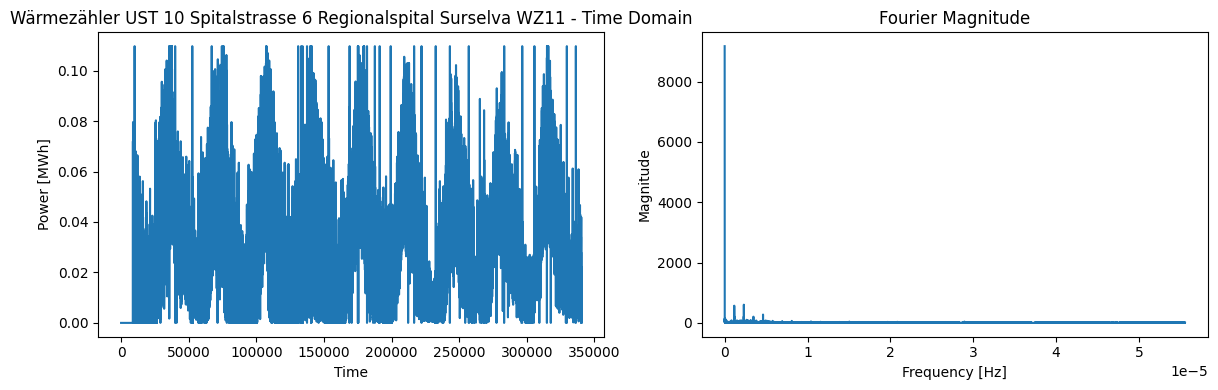

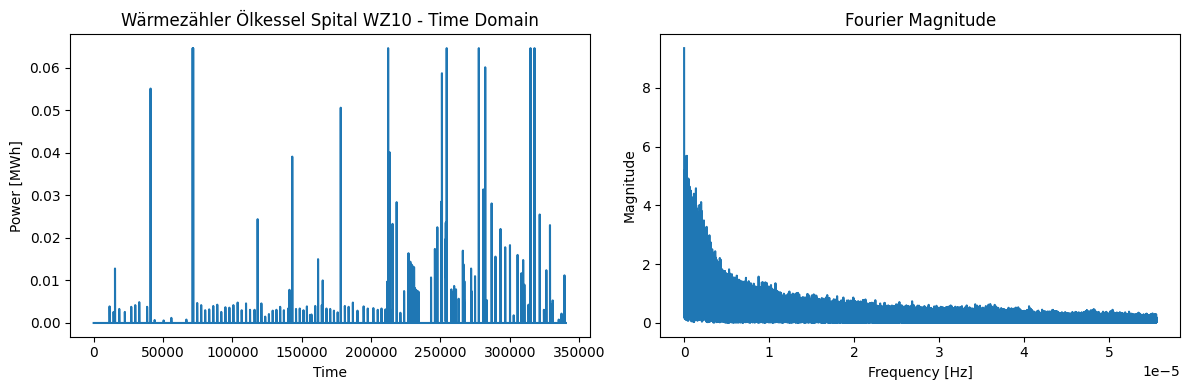

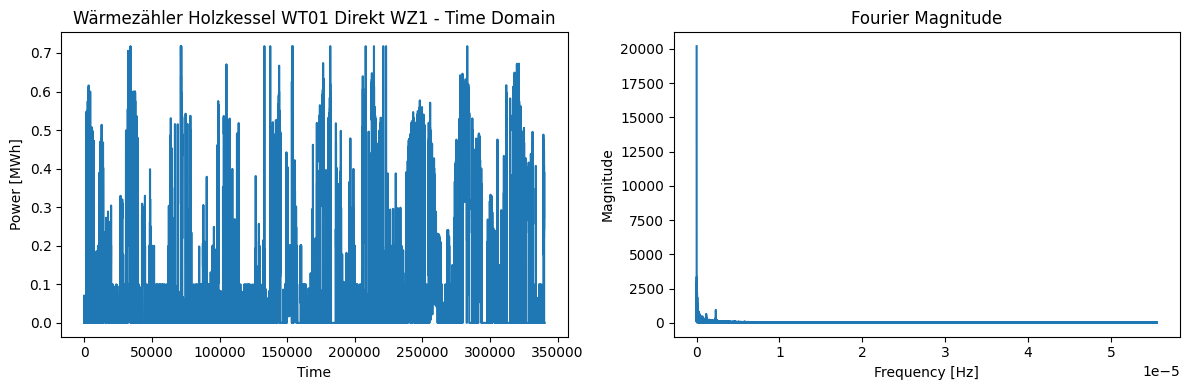

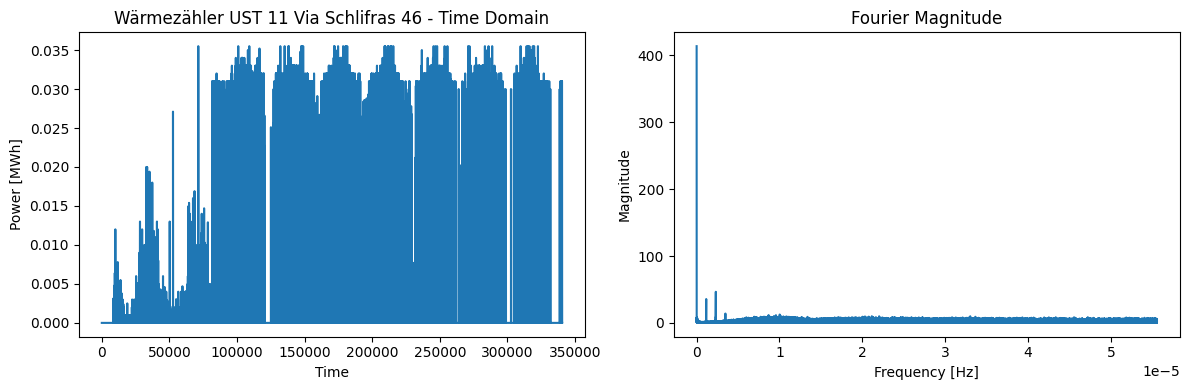

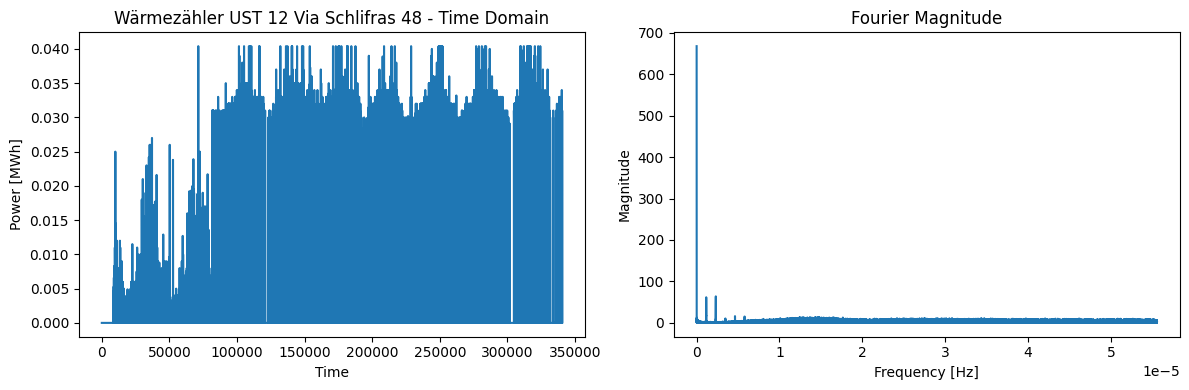

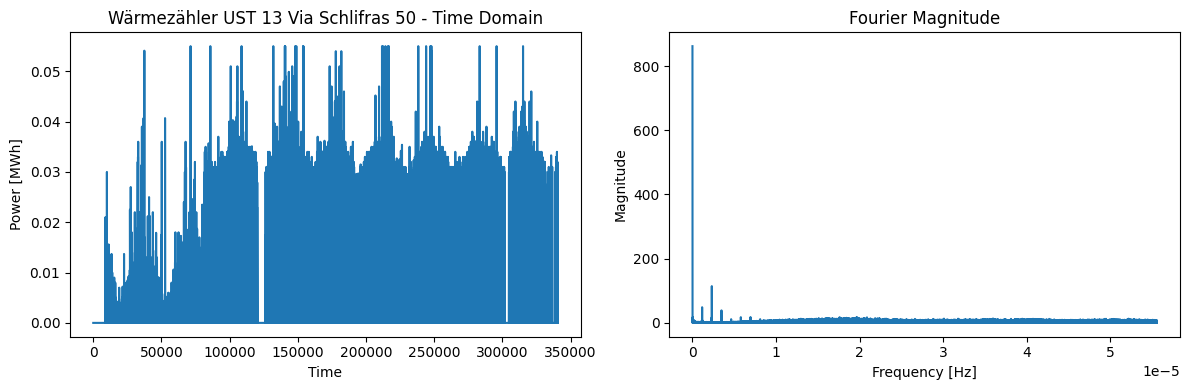

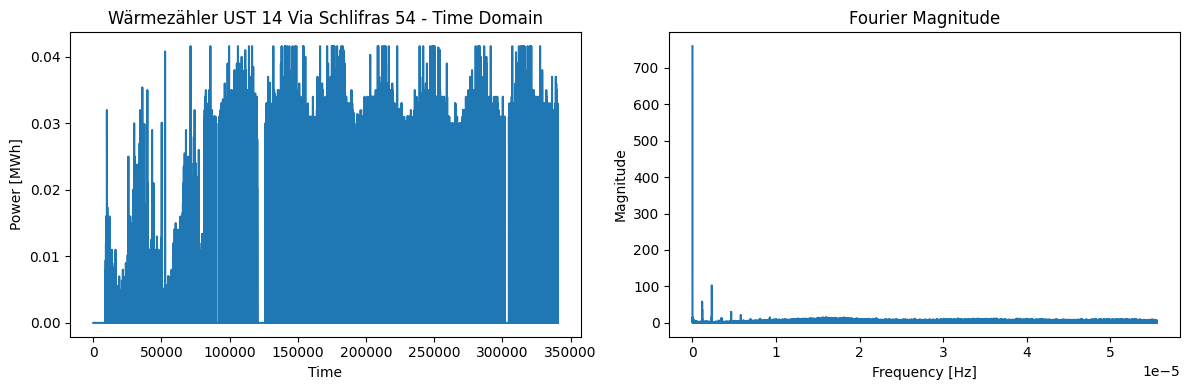

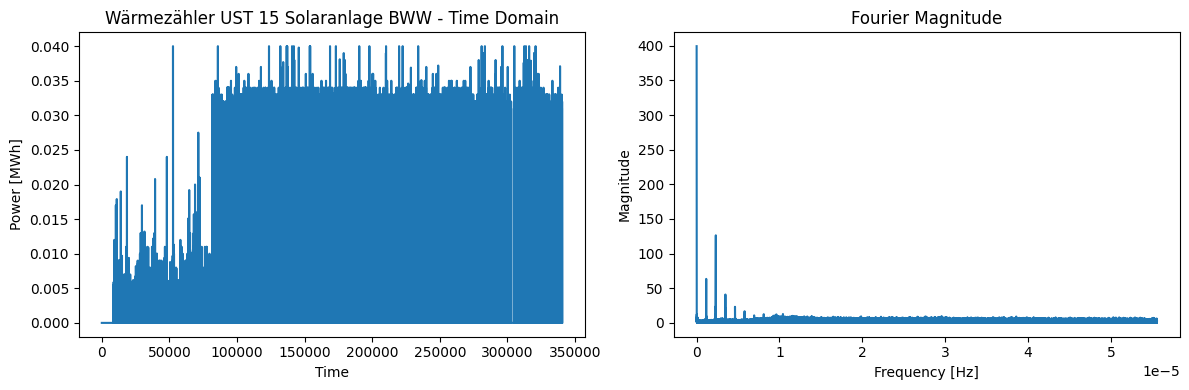

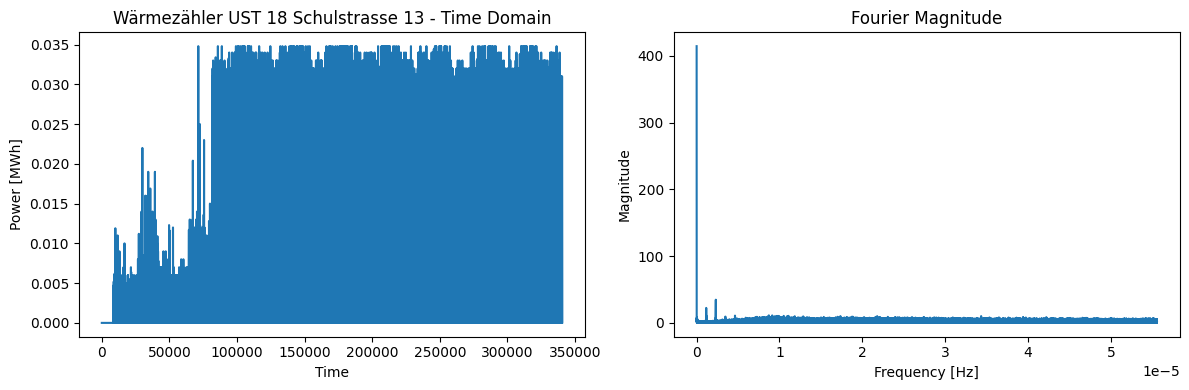

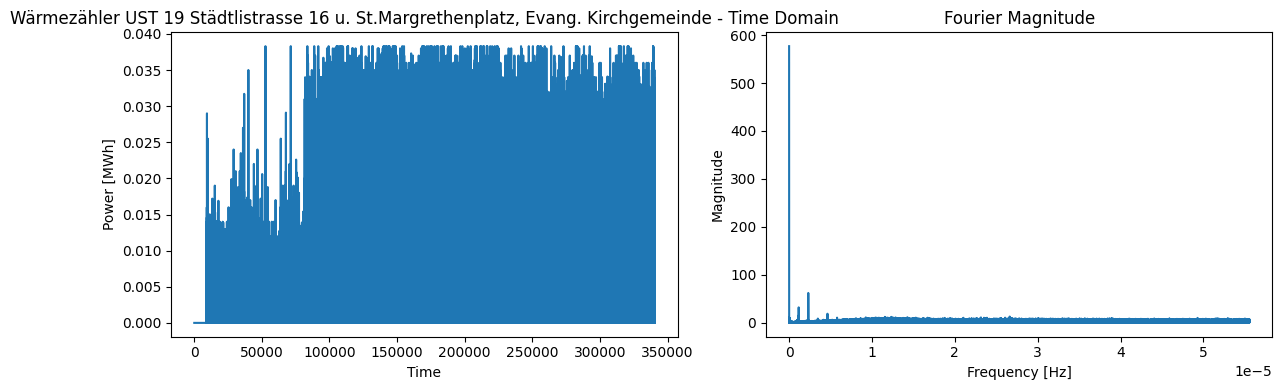

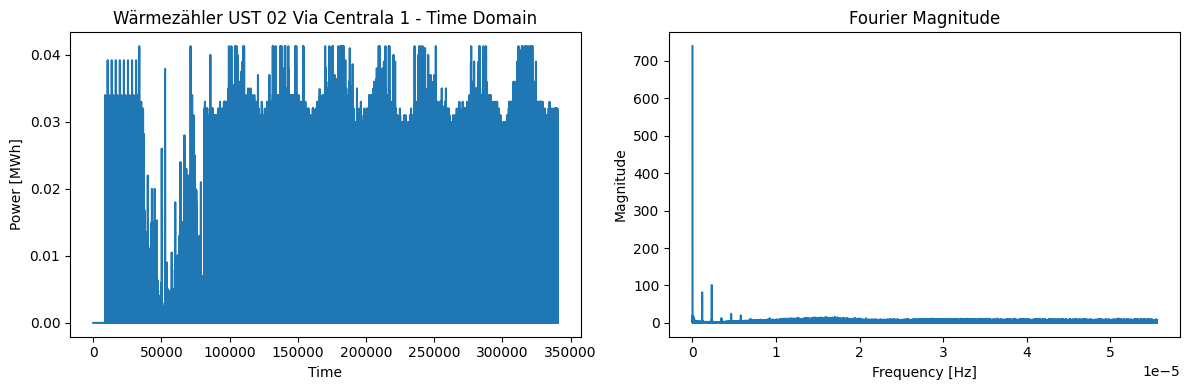

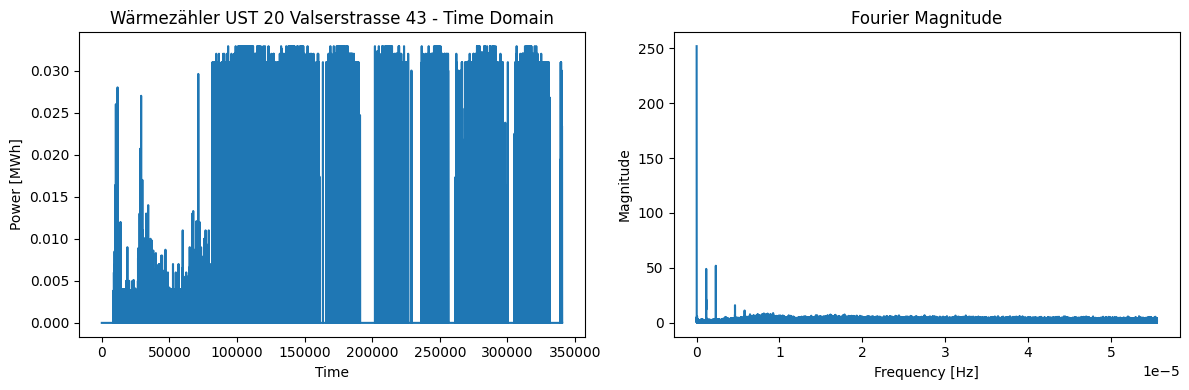

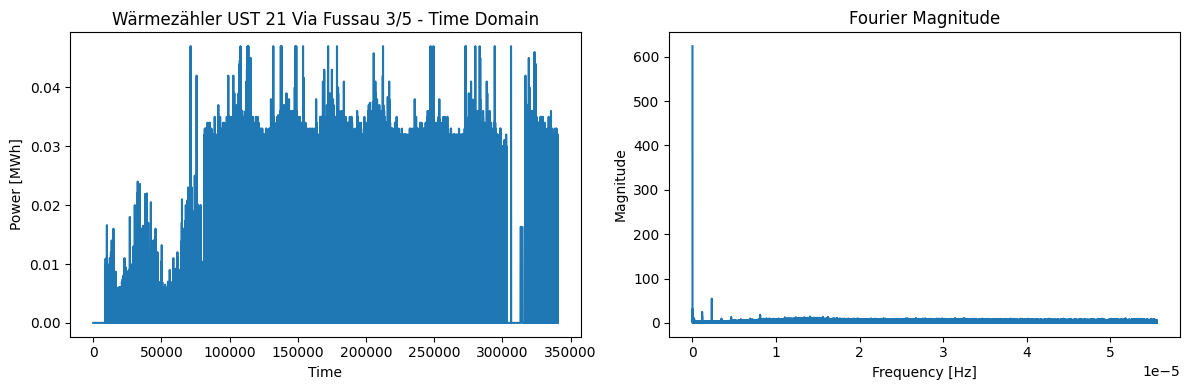

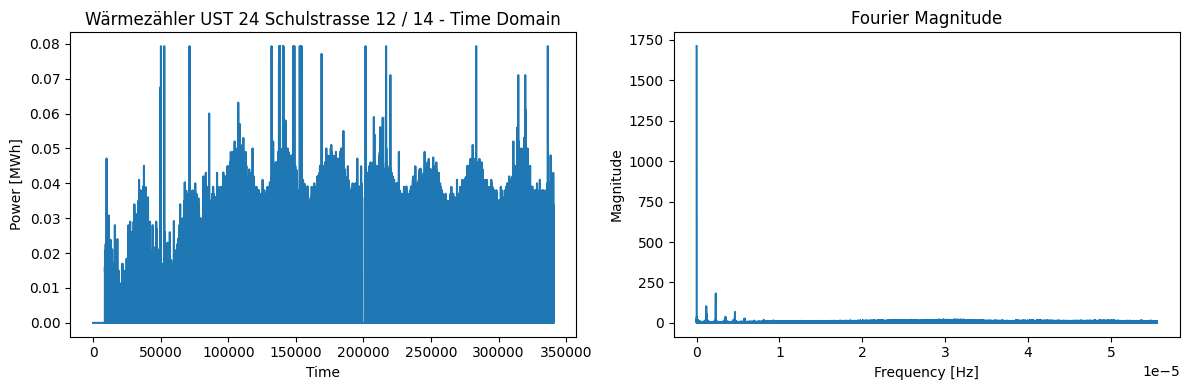

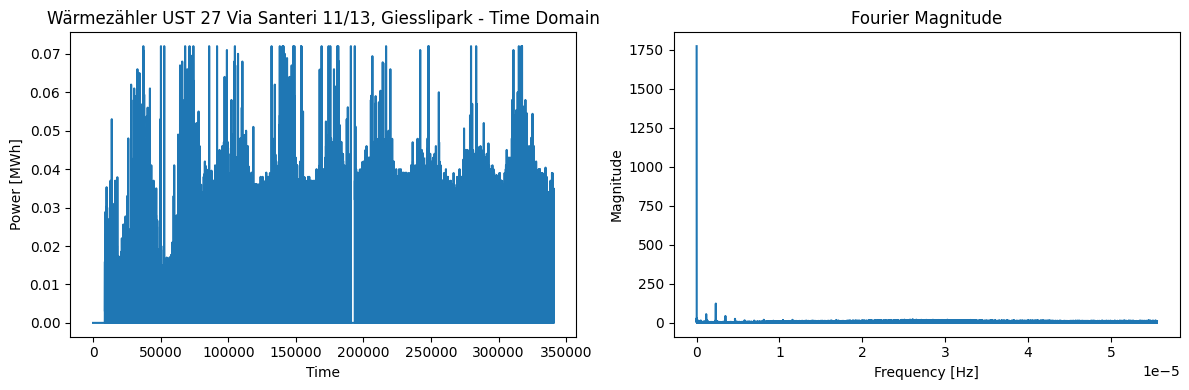

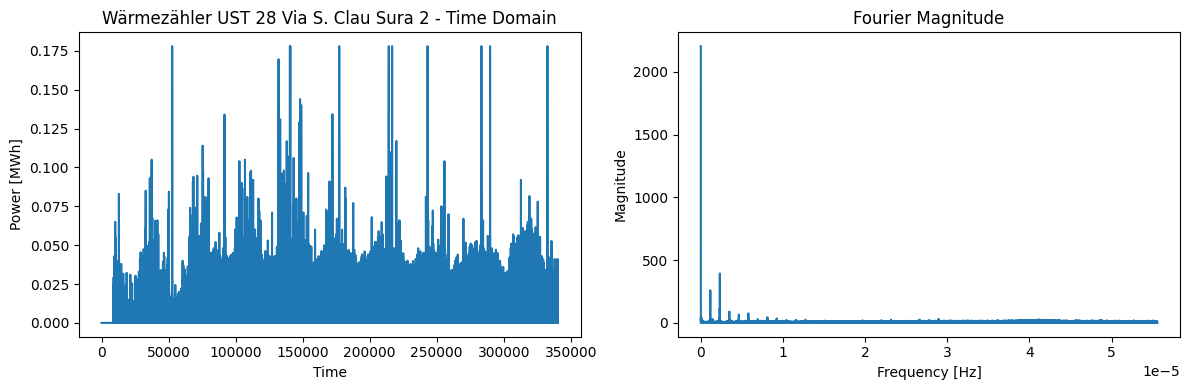

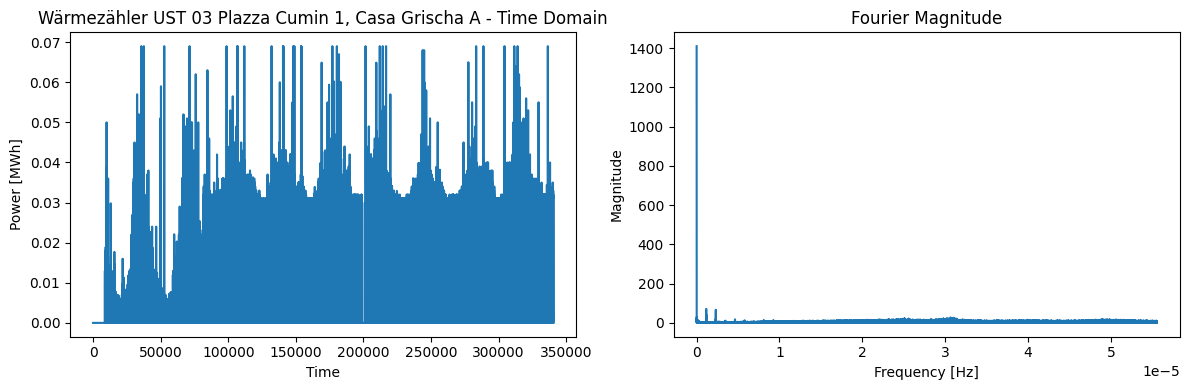

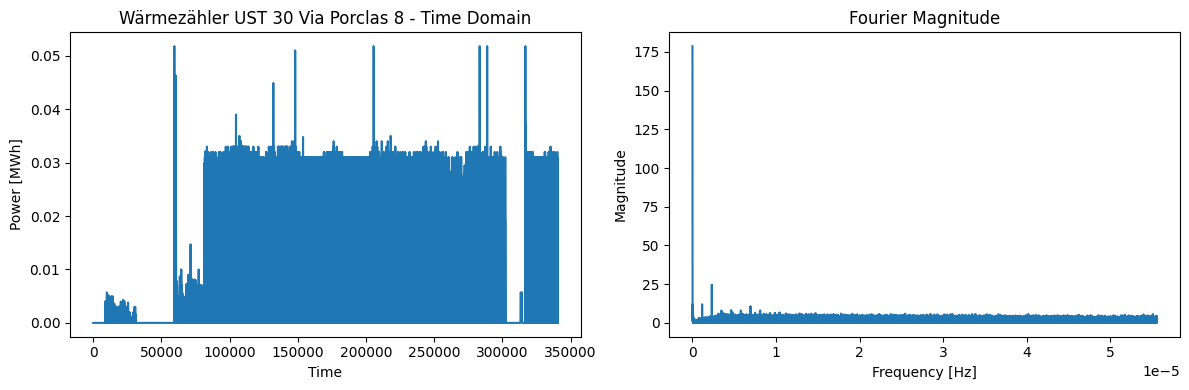

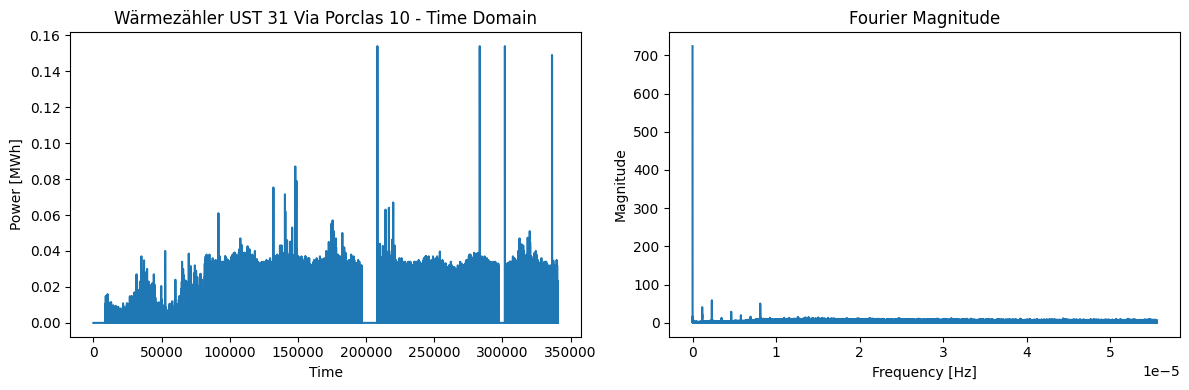

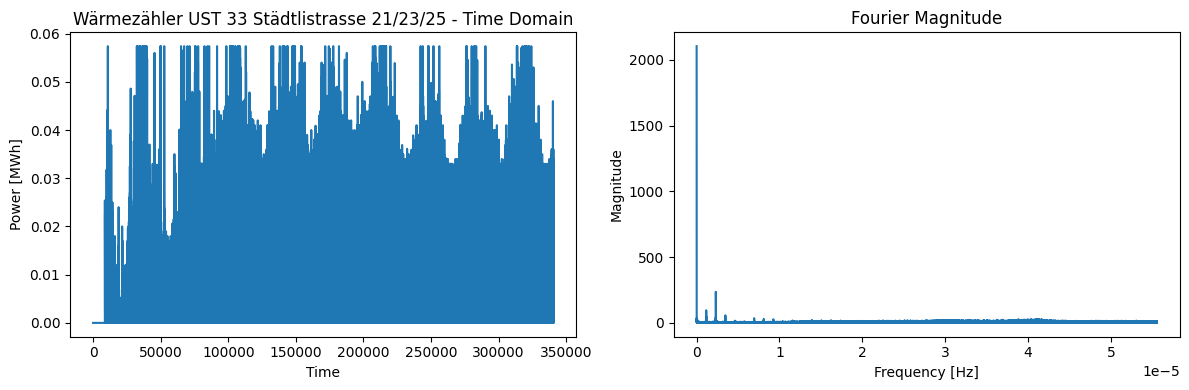

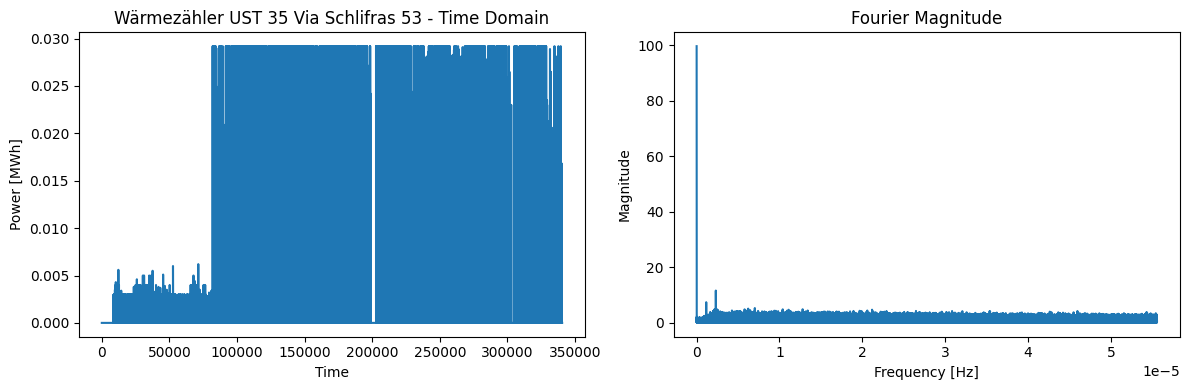

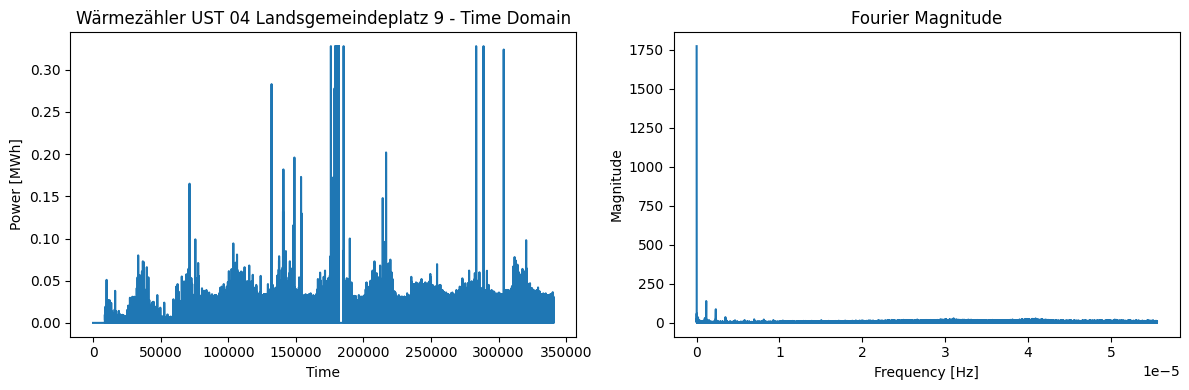

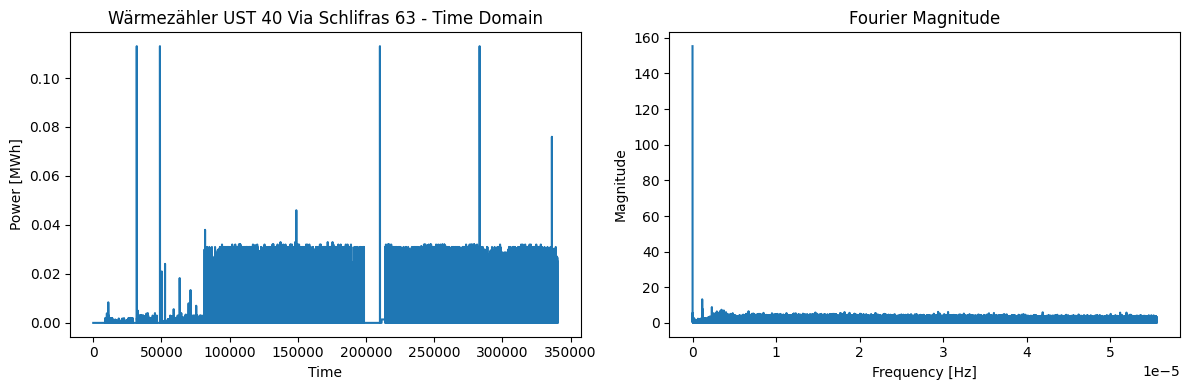

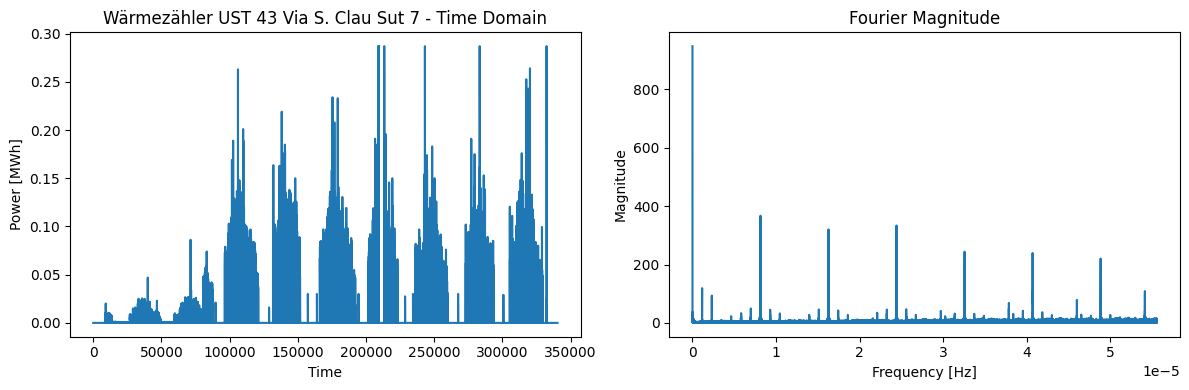

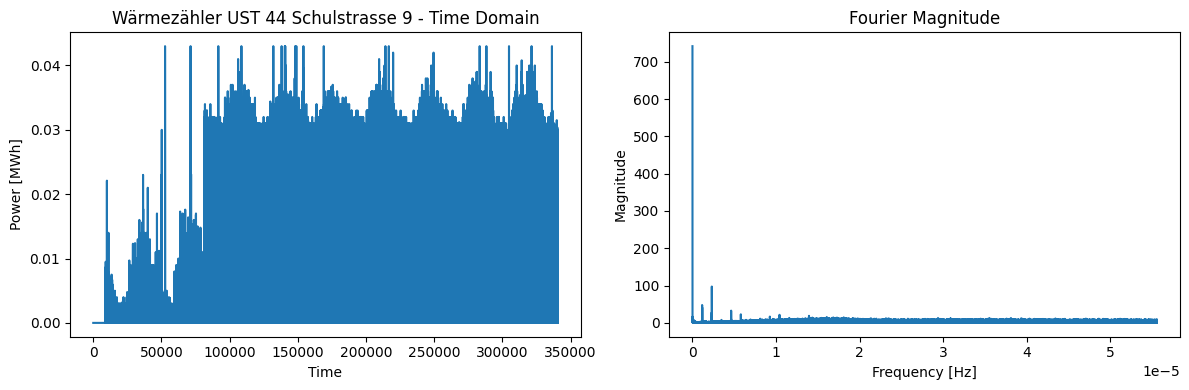

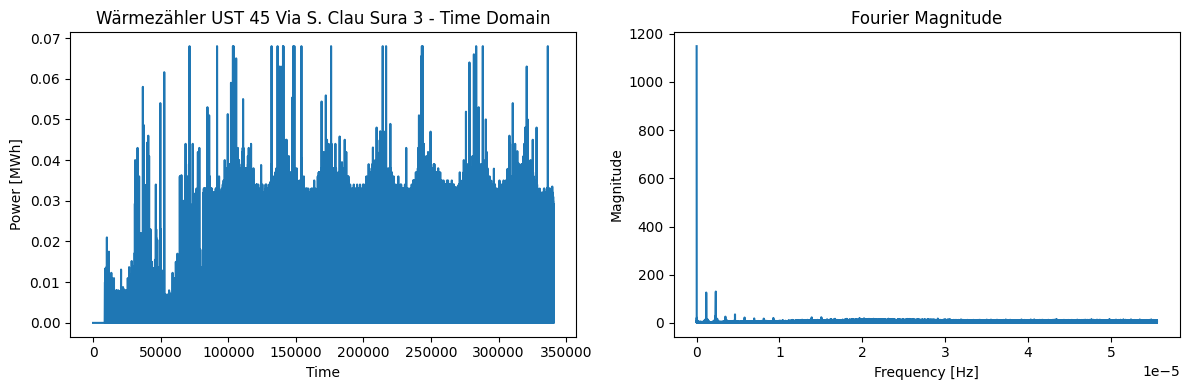

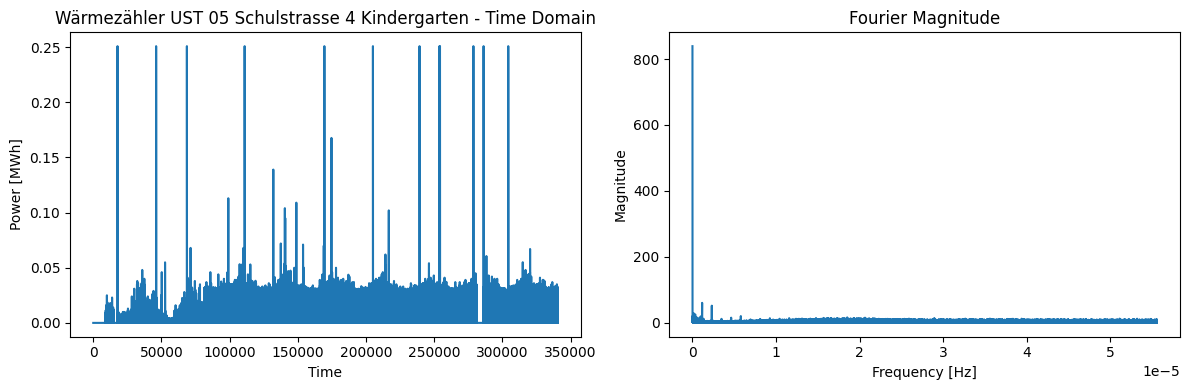

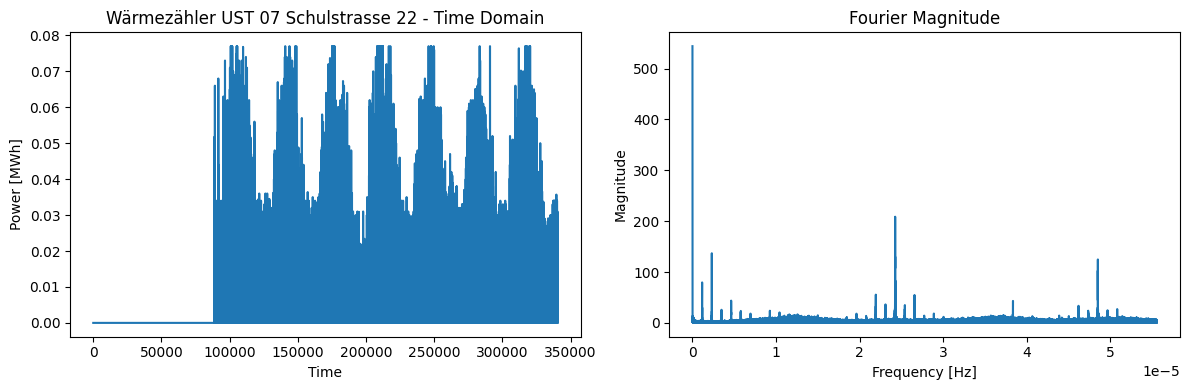

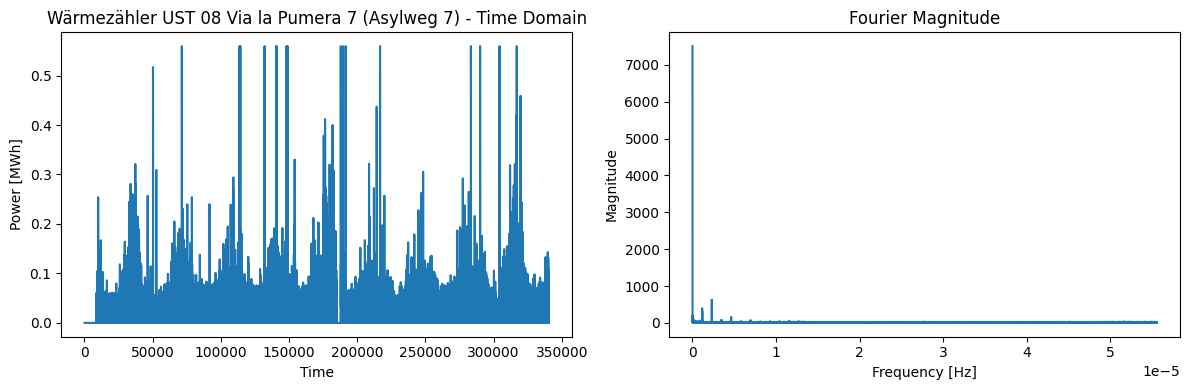

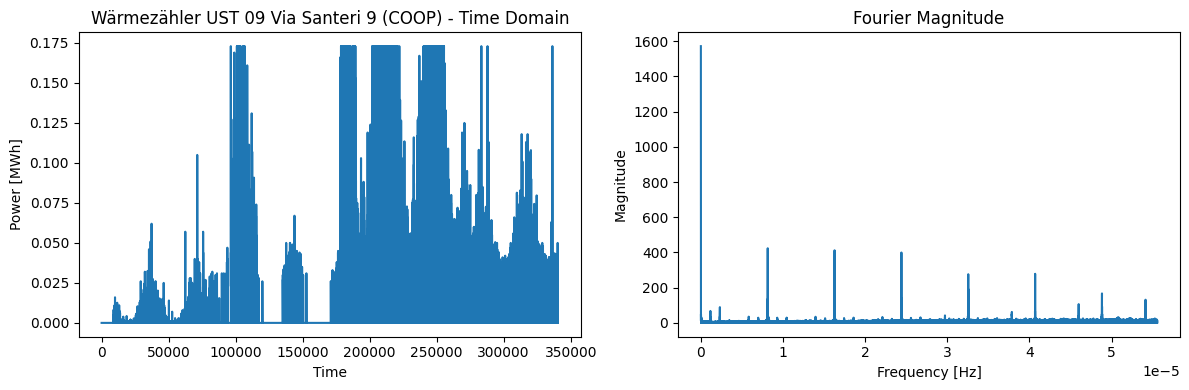

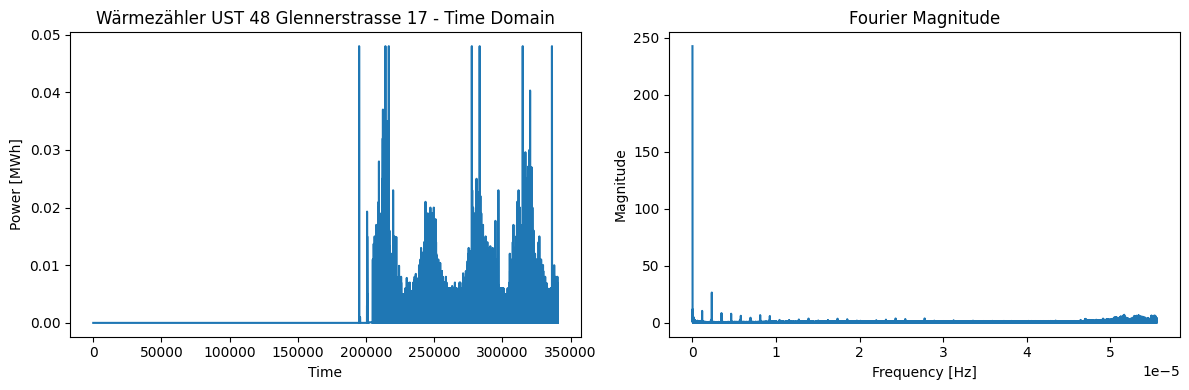

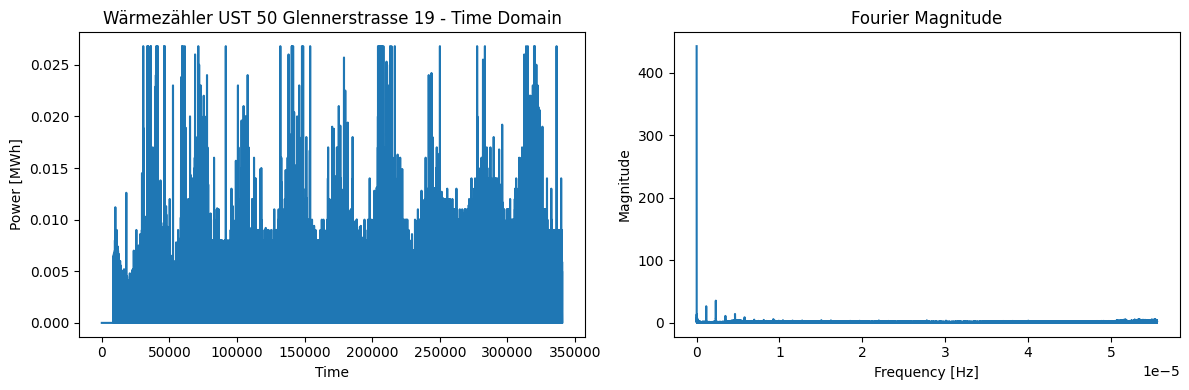

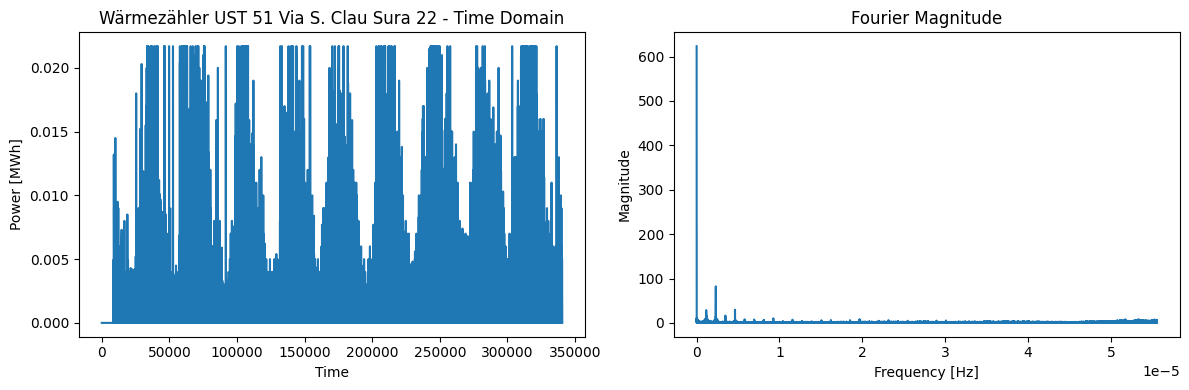

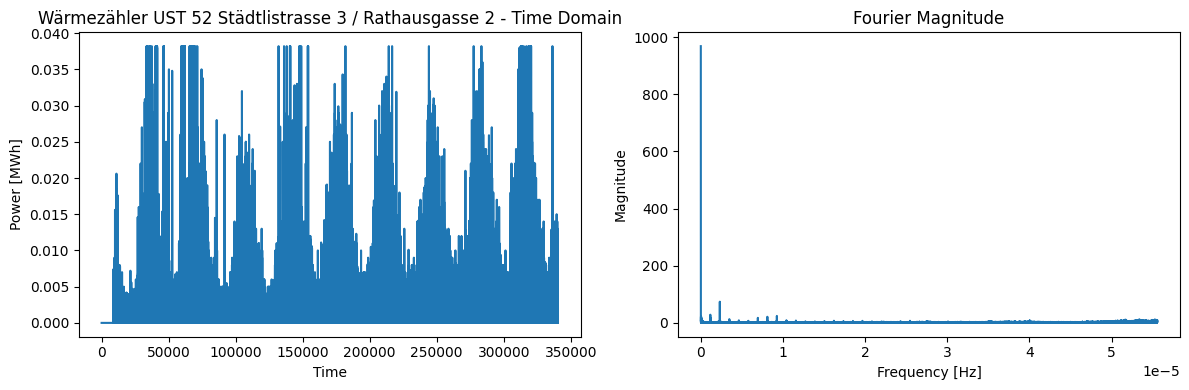

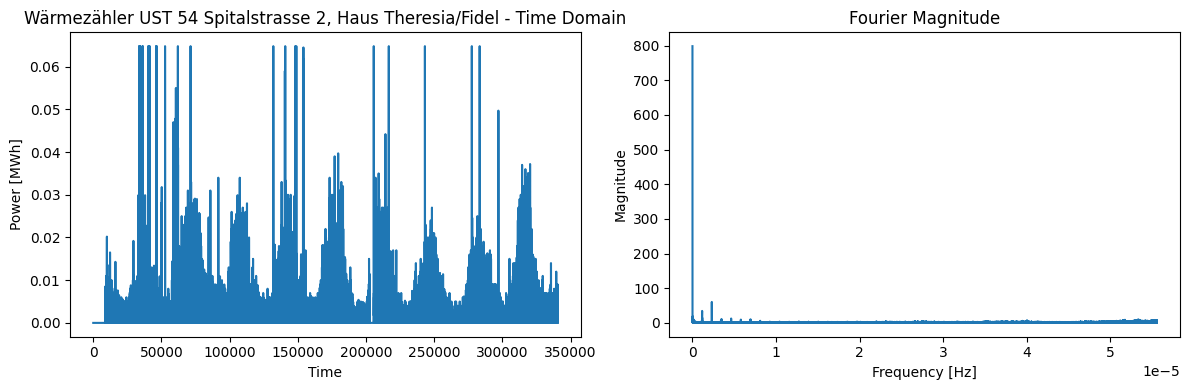

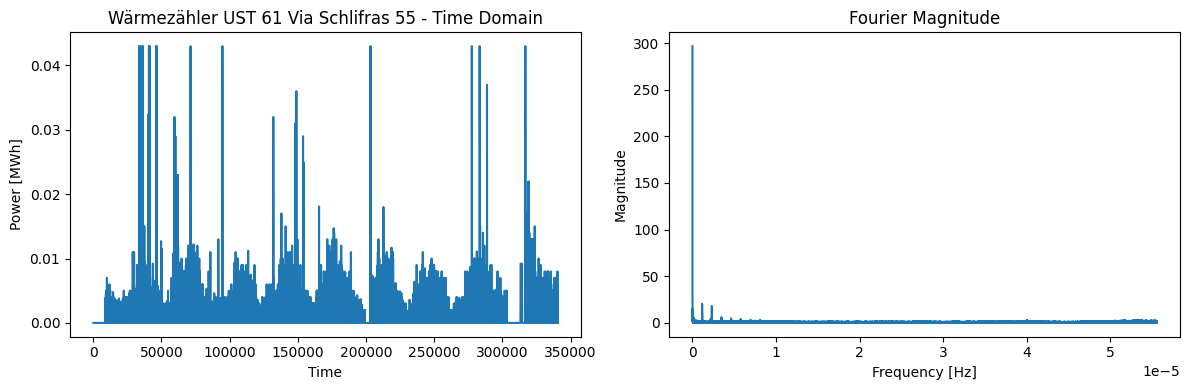

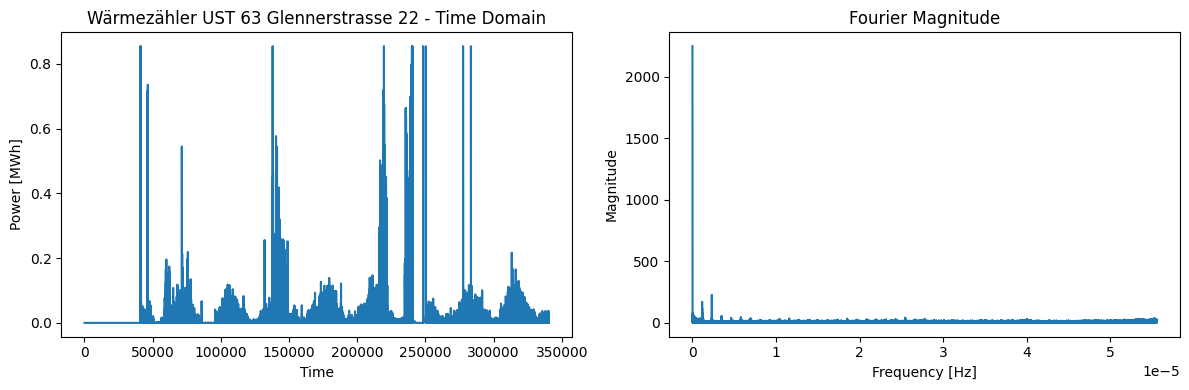

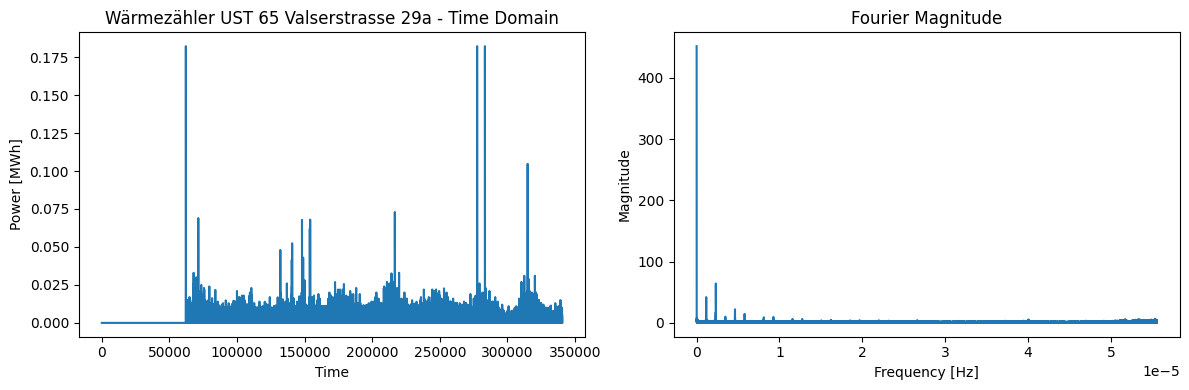

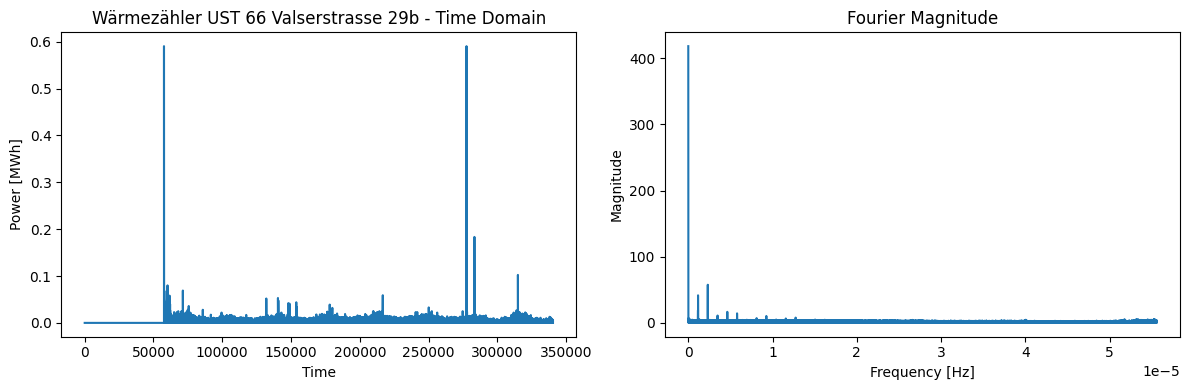

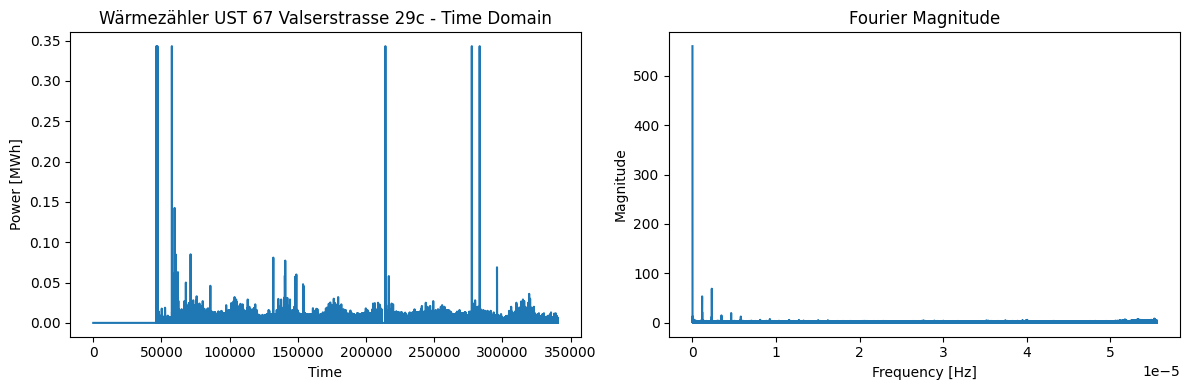

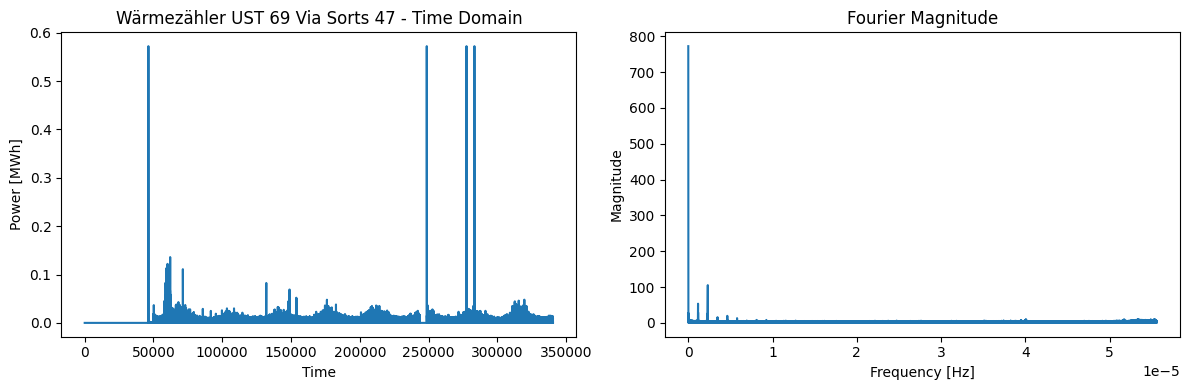

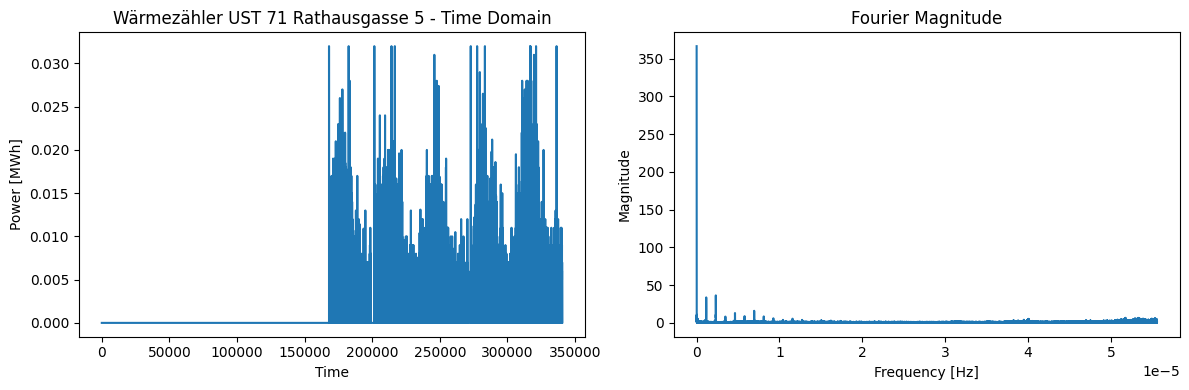

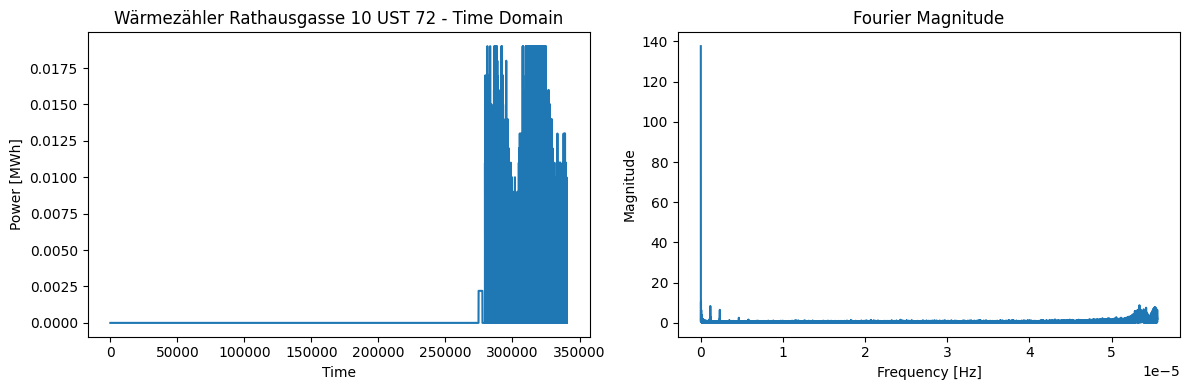

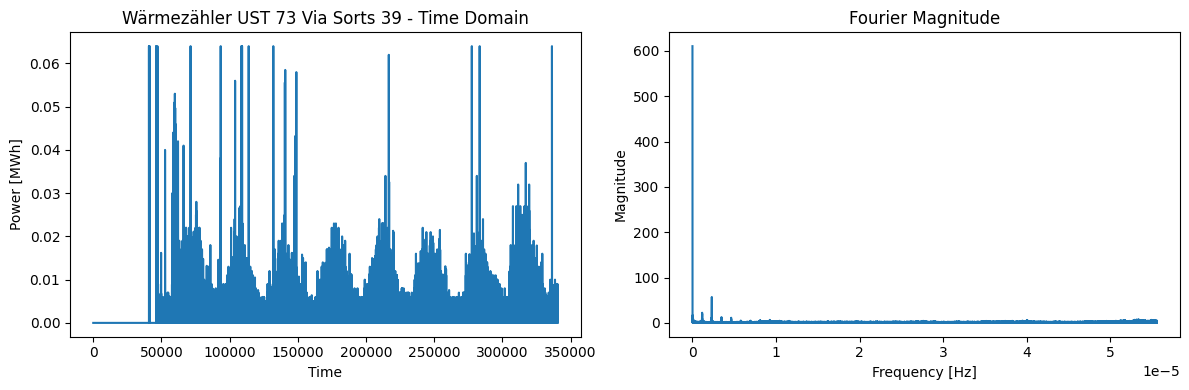

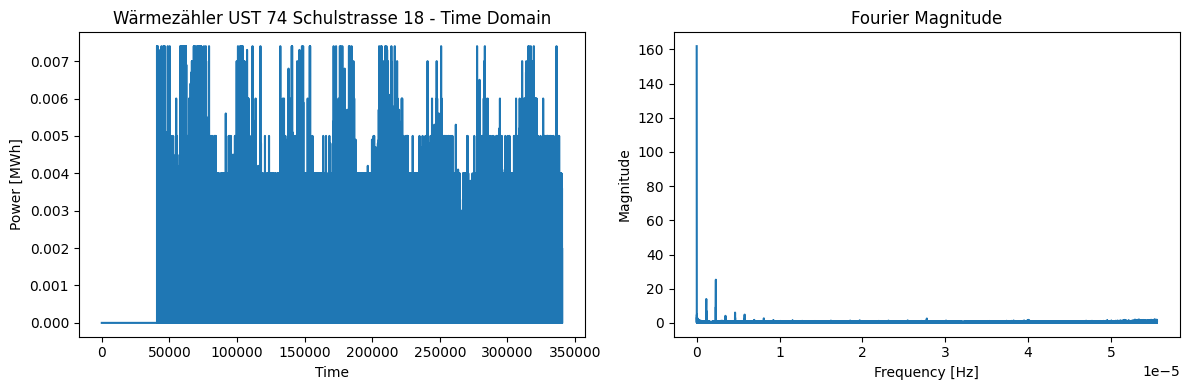

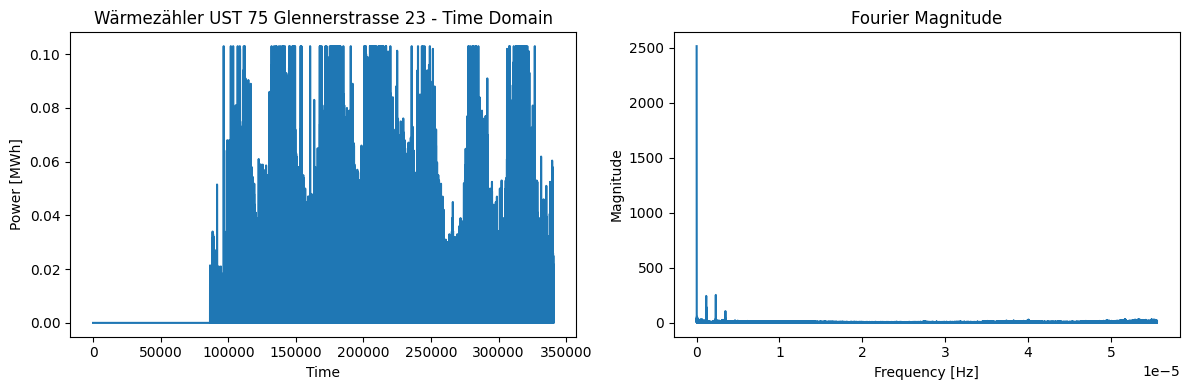

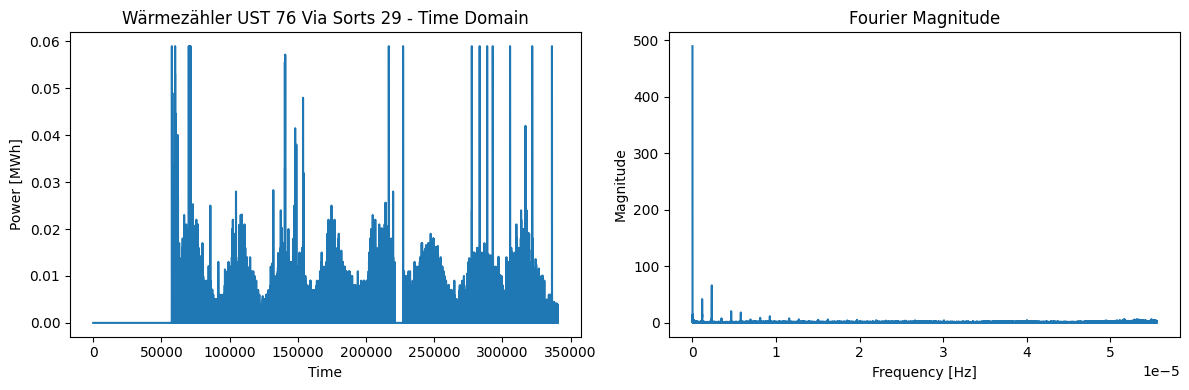

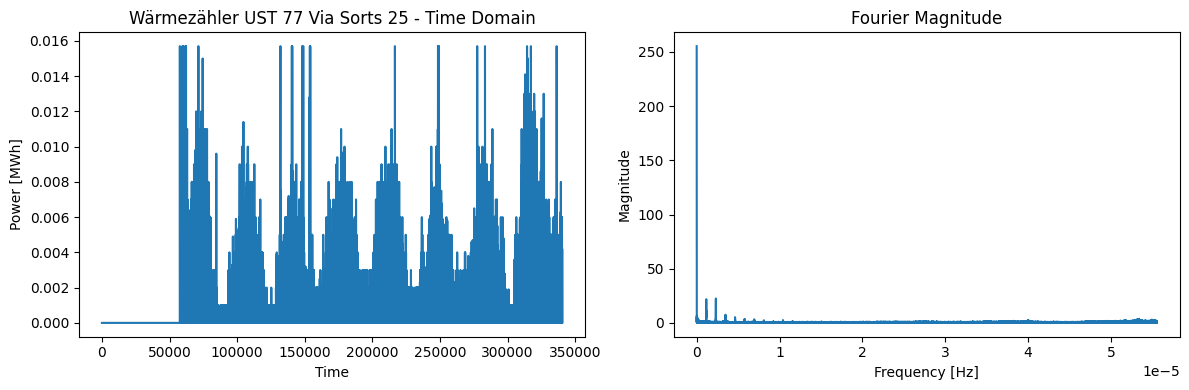

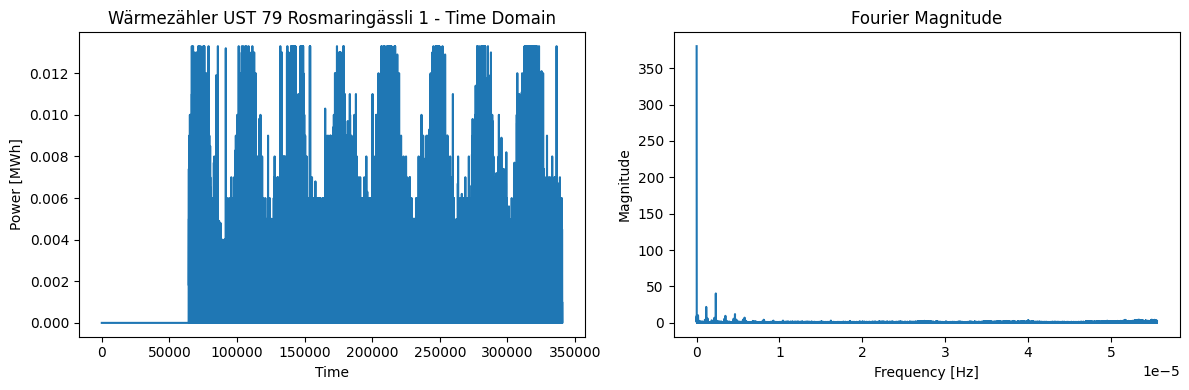

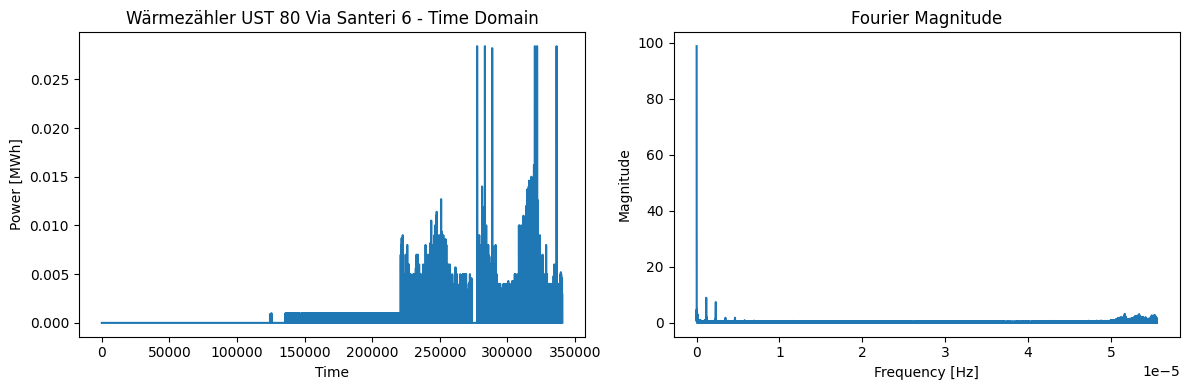

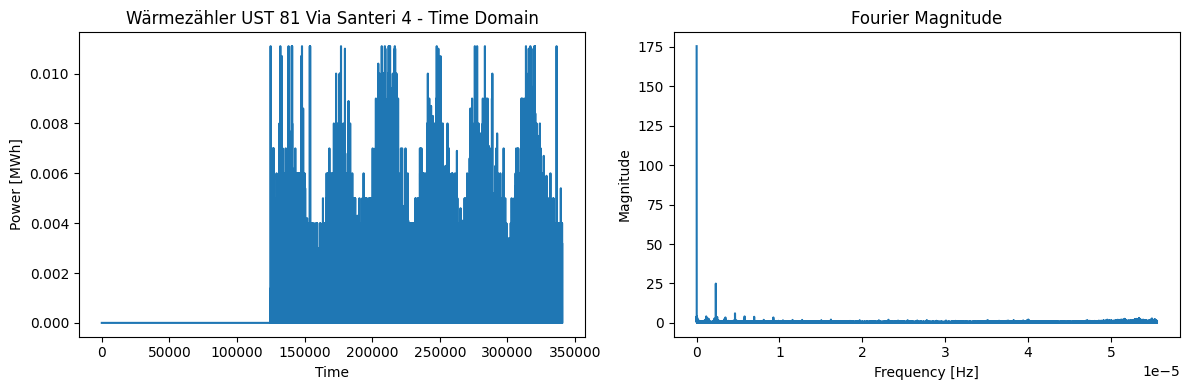

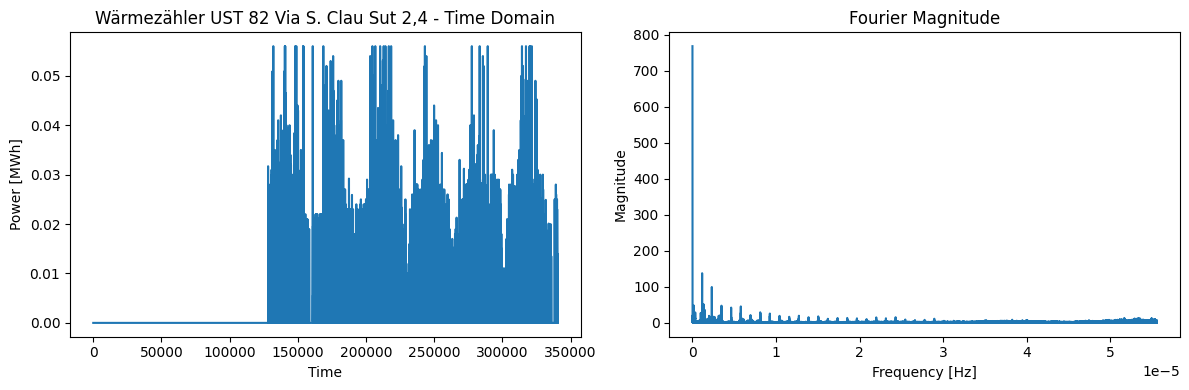

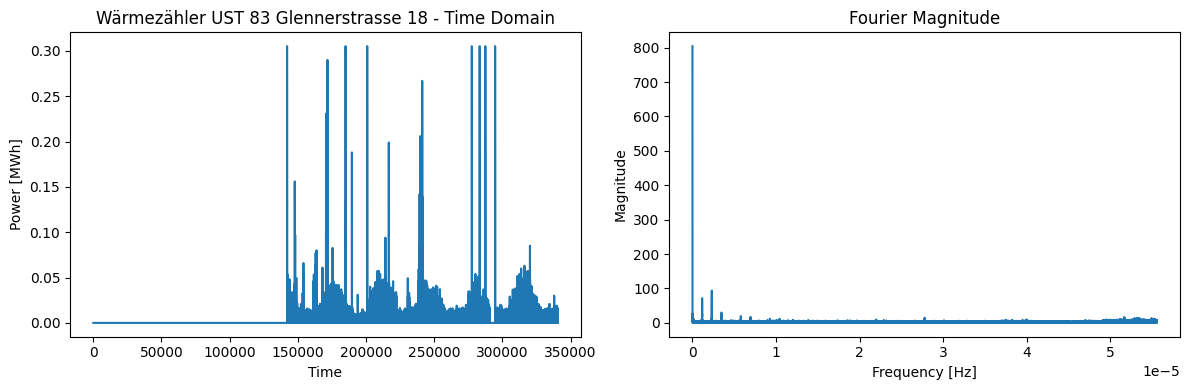

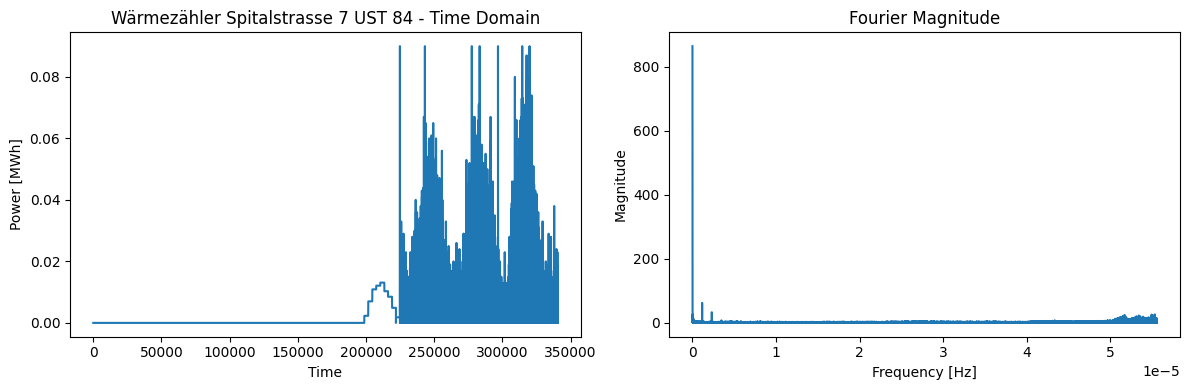

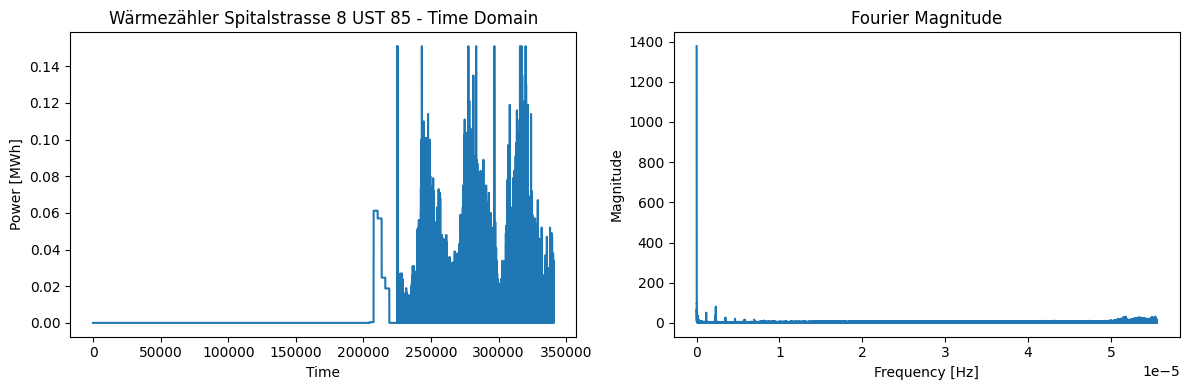

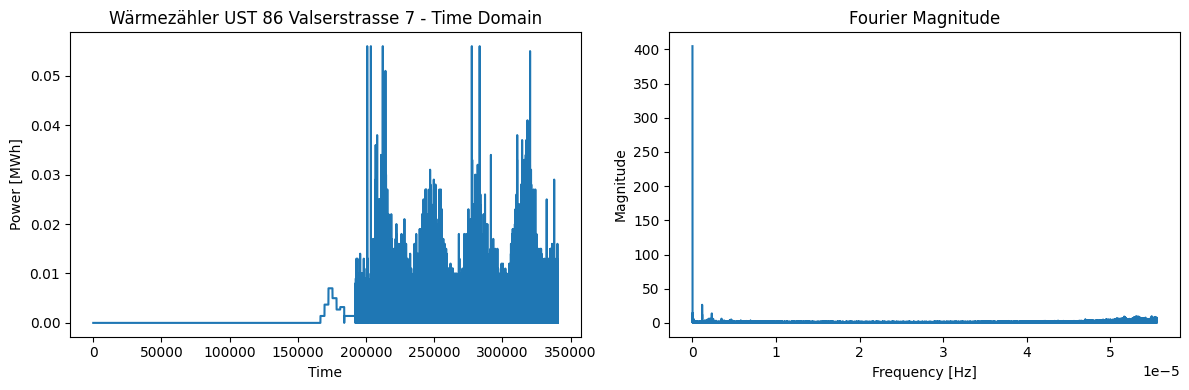

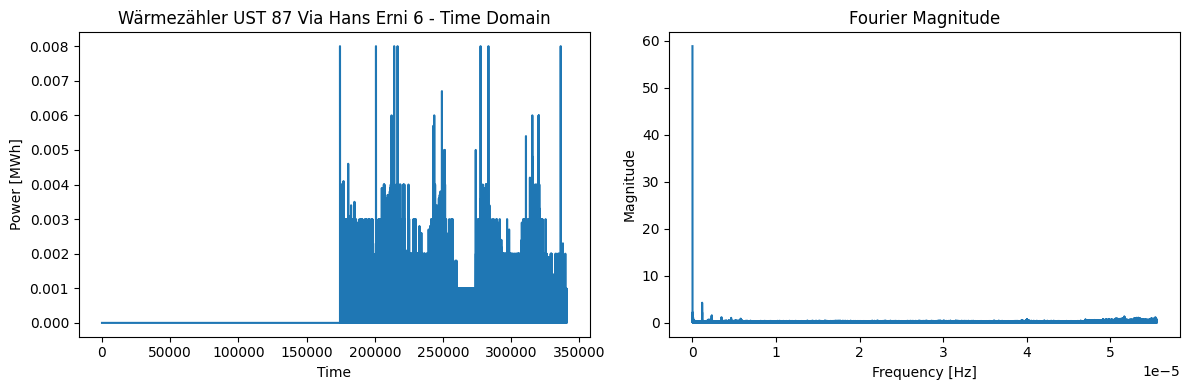

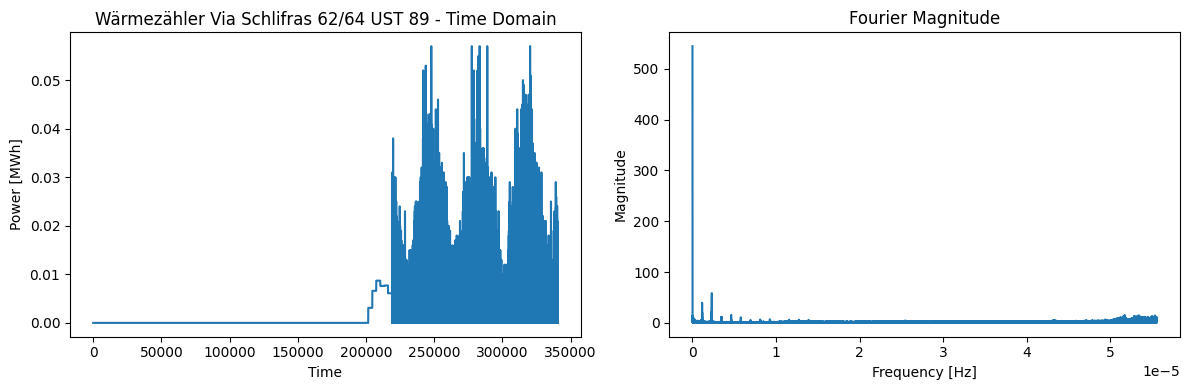

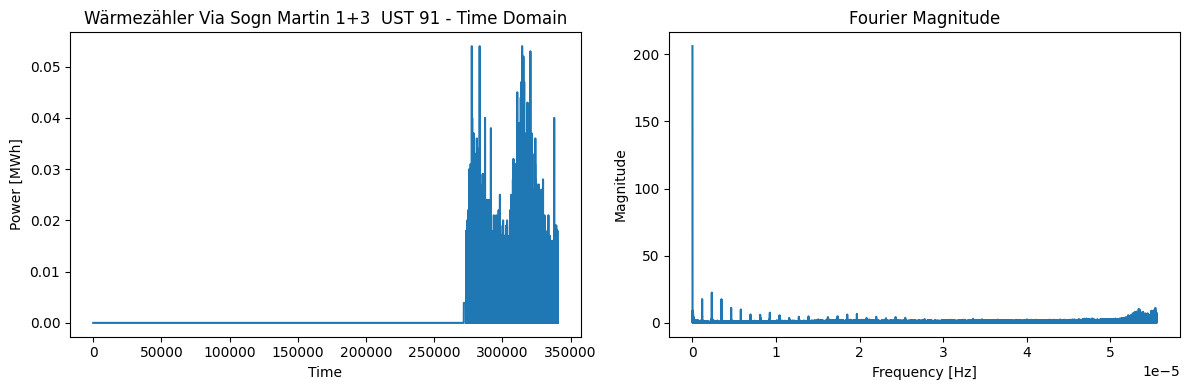

after: 59 sensors


In [28]:


valid_col = []
dt = 9000
plot = True

print(f"before: {len(sensor_columns)} sensors")
for col in sensor_columns:


    # Filter zero values before computing mean and std

    values = df[col].values

    nonzero = values > EPS
    values_tmp = values[nonzero]
    time_tmp = time[nonzero]


    mean = np.mean(values_tmp)
    std = np.std(values_tmp)

    # Ignore outliers
    mask = (values <= mean + 3 * std) & (values >= 0) # do not take negative values
    values = values[mask]
    time_tmp = time[mask]

    max_after = np.max(values)

    # Replace outliers in the dataframe with the max_after value
    df.loc[~mask, col] = max_after


    max_power = np.argmax(values)
    max_date = df.iloc[max_power]['Time'].month
    
    # Check if max is in winter
    valid = max_date in [1, 2, 11, 12]
    if valid:
        valid_col.append(col)

    if plot and valid:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Time series plot
        values = df[col].values
        axes[0].plot(range(len(values)), values)
        axes[0].set_title(f"{col} - Time Domain")
        axes[0].set_xlabel("Time")
        axes[0].set_ylabel("Power [MWh]")

        # Fourier transform
        n = len(values)
        fft_vals = np.fft.fft(values)
        fft_freq = np.fft.fftfreq(n, d=dt)  # use fixed sampling interval
        magnitude = np.abs(fft_vals)

        # frequencies whose magnitude is above threshold
        mask_freq =  (fft_freq >= 0) # & (magnitude >= 50)
        fft_freq = fft_freq[mask_freq]
        magnitude = magnitude[mask_freq]

        axes[1].plot(fft_freq, magnitude)
        axes[1].set_title("Fourier Magnitude")
        axes[1].set_xlabel("Frequency [Hz]")
        axes[1].set_ylabel("Magnitude")

        plt.tight_layout()
        plt.show()

sensor_columns = valid_col
df = df[['Time'] + valid_col]
print(f"after: {len(sensor_columns)} sensors")


### Get intersection

In [29]:
max_nz = datetime(2003, 1, 1) # date in the past
idx_intersection = -1

for col in sensor_columns:

    values = df[col].values
    nonzero = df[col] > EPS
    nz_idx = np.argmax(nonzero) # argmax takes first occurence of max
    first_nz = df.iloc[nz_idx]['Time']
    if first_nz > max_nz:
        max_nz = first_nz
        idx_intersection = nz_idx


max_nz


    

Timestamp('2023-11-01 00:00:00')

In [30]:
df_intersection = df.iloc[idx_intersection:]


In [31]:
df_intersection.set_index('Time', inplace=True)

df_intersection.head()

,Wärmezähler UST 10 Spitalstrasse 6 Regionalspital Surselva WZ11,Wärmezähler Ölkessel Spital WZ10,Wärmezähler Holzkessel WT01 Direkt WZ1,Wärmezähler UST 11 Via Schlifras 46,Wärmezähler UST 12 Via Schlifras 48,Wärmezähler UST 13 Via Schlifras 50,Wärmezähler UST 14 Via Schlifras 54,Wärmezähler UST 15 Solaranlage BWW,Wärmezähler UST 18 Schulstrasse 13,"Wärmezähler UST 19 Städtlistrasse 16 u. St.Margrethenplatz, Evang. Kirchgemeinde",...,Wärmezähler UST 80 Via Santeri 6,Wärmezähler UST 81 Via Santeri 4,"Wärmezähler UST 82 Via S. Clau Sut 2,4",Wärmezähler UST 83 Glennerstrasse 18,Wärmezähler Spitalstrasse 7 UST 84,Wärmezähler Spitalstrasse 8 UST 85,Wärmezähler UST 86 Valserstrasse 7,Wärmezähler UST 87 Via Hans Erni 6,Wärmezähler Via Schlifras 62/64 UST 89,Wärmezähler Via Sogn Martin 1+3 UST 91
Time,,,,,,,,,,,,,,,,,,,,,
2023-11-01 00:00:00,0.0252,0.0,0.0,0.000,0.0021,0.000,0.0,0.0,0.0,0.0,...,0.0,0.000,0.000,0.000,0.019,0.004,0.004,0.000,0.004,0.003
2023-11-01 00:15:00,0.0278,0.0,0.0,0.000,0.0000,0.000,0.0,0.0,0.0,0.0,...,0.0,0.001,0.004,0.006,0.000,0.000,0.000,0.002,0.000,0.000
2023-11-01 00:30:00,0.0236,0.0,0.0,0.000,0.0000,0.031,0.0,0.0,0.0,0.0,...,0.0,0.000,0.000,0.000,0.007,0.002,0.004,0.000,0.008,0.004
2023-11-01 00:45:00,0.0211,0.0,0.0,0.031,0.0000,0.000,0.0,0.0,0.0,0.0,...,0.0,0.001,0.004,0.007,0.000,0.000,0.000,0.001,0.000,0.000
2023-11-01 01:00:00,0.0161,0.0,0.0,0.000,0.0000,0.000,0.0,0.0,0.0,0.0,...,0.0,0.000,0.000,0.000,0.014,0.004,0.005,0.000,0.008,0.004


In [ ]:
# sanity check
torch_dataset = SpatioTemporalDataset(target=df_intersection,
                                      horizon=12,
                                      window=12,
                                      stride=1)


torch_dataset.shape


(65807, 59, 1)

In [33]:
df_intersection.to_csv(os.path.join(DATA_FOLDER, 'EWZ_cleaned.csv'))